# Champion Experiments: Final Optimization & Deployment

## Environment Setup & Experimental Engine

In [ ]:
import os
import sys
from pathlib import Path

# 1. Get current working directory
current_dir = Path.cwd()

# 2. If we are inside one of the subfolders, step back up to the parent (PROJECT2)
if current_dir.name in ['models', 'experiments', 'data_prep']:
    os.chdir(current_dir.parent)
    
# 3. Add the root project folder to the system path ONLY if it isn't already there
project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Working directory safely set to: {Path.cwd()}")

In [82]:
import os
import ssl
import certifi
import torch
import torch.nn.functional as F
from torch.nn import Linear
import torch_geometric.transforms as T
from torch_geometric.nn import APPNP
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import dropout_edge
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 1. SSL & Device Setup
os.environ['SSL_CERT_FILE'] = certifi.where()
ssl._create_default_https_context = ssl._create_unverified_context
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# 2. Champion Hyperparameters (From 80/10/10 APPNP run)
CHAMPION_LR = 0.01
CHAMPION_HID_DIM = 64
CHAMPION_DROPOUT = 0.3
CHAMPION_K = 10
CHAMPION_ALPHA = 0.1

# 3. Training & Plotting Engine
def run_experiment(model, data, lr, epochs=200, use_dropedge=False, dropedge_p=0.2, use_scheduler=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
    # NEW: Initialize the Scheduler
    # factor=0.5 cuts LR in half, patience=20 waits for 20 epochs of no improvement
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
    
    criterion = torch.nn.CrossEntropyLoss()
    train_losses, val_losses = [], []
    
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        if use_dropedge:
            train_edge_index, _ = dropout_edge(data.edge_index, p=dropedge_p, training=True)
        else:
            train_edge_index = data.edge_index
            
        out = model(data.x, train_edge_index)
        t_loss = criterion(out[data.train_mask], data.y[data.train_mask])
        t_loss.backward()
        optimizer.step()
        train_losses.append(t_loss.item())
        
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            v_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_losses.append(v_loss.item())
            
            # NEW: Step the scheduler based on validation loss
            if use_scheduler:
                scheduler.step(v_loss)
            
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        y_pred = out.argmax(dim=1)[data.test_mask].cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()
        
    test_acc = accuracy_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred, average='macro')
    return train_losses, val_losses, test_acc, test_f1

def plot_experiment(train_losses, val_losses, title, acc, f1):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='teal', linewidth=2, alpha=0.8)
    plt.plot(val_losses, label='Validation Loss', color='salmon', linewidth=2)
    plt.title(f"{title}\nTest Accuracy: {acc*100:.2f}% | Macro-F1: {f1*100:.2f}%", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("Setup Complete!")

Setup Complete!


## 🔬 Experiment 1: Impact Analysis of Feature Normalization

--- EXPERIMENT 1: NO FEATURE NORMALIZATION ---


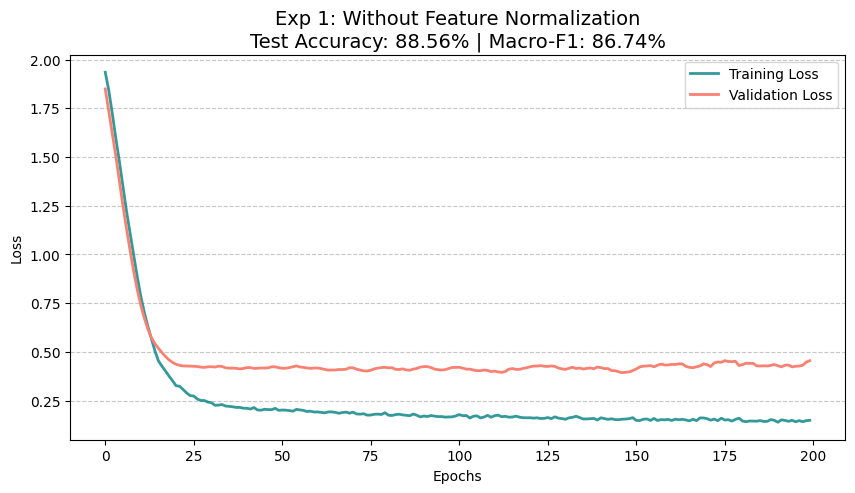

In [83]:
print("--- EXPERIMENT 1: NO FEATURE NORMALIZATION ---")

# 1. Load data WITHOUT normalization
transform_no_norm = T.Compose([
    T.RandomNodeSplit(split='train_rest', num_val=0.1, num_test=0.1)
])
dataset_exp1 = Planetoid(root='./data/Cora', name='Cora', transform=transform_no_norm)
data_exp1 = dataset_exp1[0].to(device)

# 2. Define standard APPNP
class APPNP_Standard(torch.nn.Module):
    def __init__(self, hidden_channels, dropout_p, K, alpha):
        super(APPNP_Standard, self).__init__()
        self.dropout_p = dropout_p
        self.lin1 = Linear(dataset_exp1.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset_exp1.num_classes)
        self.prop1 = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        out = self.lin2(x)
        return self.prop1(out, edge_index)

# 3. Train & Plot
model_exp1 = APPNP_Standard(CHAMPION_HID_DIM, CHAMPION_DROPOUT, CHAMPION_K, CHAMPION_ALPHA).to(device)
t_loss1, v_loss1, acc1, f1_1 = run_experiment(model_exp1, data_exp1, lr=CHAMPION_LR)
plot_experiment(t_loss1, v_loss1, "Exp 1: Without Feature Normalization", acc1, f1_1)

## 🛡️ Experiment 2: Structural Regularization via Random Edge Dropout

--- EXPERIMENT 2: RANDOM EDGE DROPOUT (p=0.2) ---


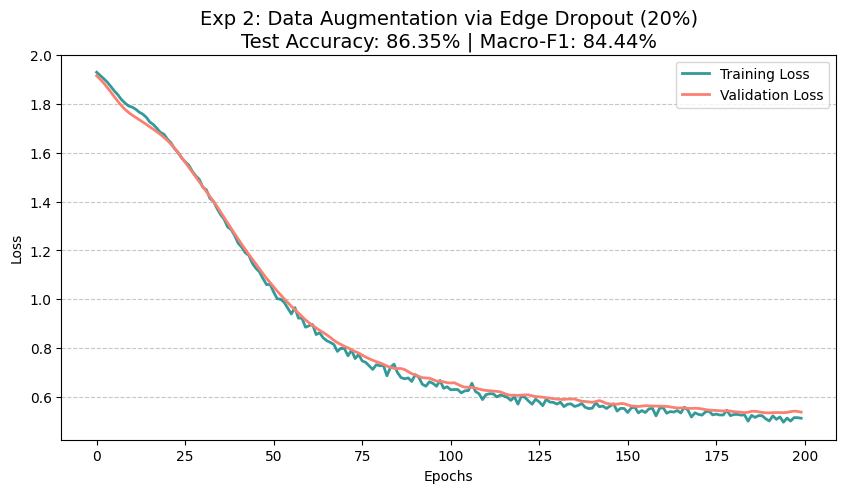

In [84]:
print("--- EXPERIMENT 2: RANDOM EDGE DROPOUT (p=0.2) ---")

# 1. Load data WITH normalization
transform_norm = T.Compose([
    T.NormalizeFeatures(),
    T.RandomNodeSplit(split='train_rest', num_val=0.1, num_test=0.1)
])
dataset_exp2 = Planetoid(root='./data/Cora', name='Cora', transform=transform_norm)
data_exp2 = dataset_exp2[0].to(device)

# 2. Train using the standard model, but turn on the Edge Dropout flag
model_exp2 = APPNP_Standard(CHAMPION_HID_DIM, CHAMPION_DROPOUT, CHAMPION_K, CHAMPION_ALPHA).to(device)
t_loss2, v_loss2, acc2, f1_2 = run_experiment(
    model_exp2, data_exp2, lr=CHAMPION_LR, 
    use_dropedge=True, dropedge_p=0.2 # <--- Augmentation applied here
)
plot_experiment(t_loss2, v_loss2, "Exp 2: Data Augmentation via Edge Dropout (20%)", acc2, f1_2)

## ⛓️ Experiment 3: Feature Preservation via MLP Residual Connections

--- EXPERIMENT 3: ADDING RESIDUAL (SKIP) CONNECTIONS ---


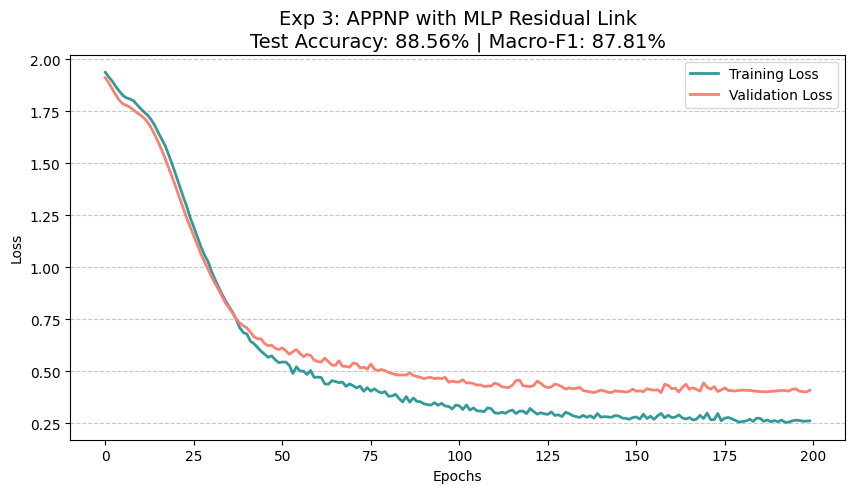

In [85]:
print("--- EXPERIMENT 3: ADDING RESIDUAL (SKIP) CONNECTIONS ---")

# We use the same normalized data_exp2 from above
# Define a modified APPNP architecture with an explicit Residual Block
class APPNP_Residual(torch.nn.Module):
    def __init__(self, hidden_channels, dropout_p, K, alpha):
        super(APPNP_Residual, self).__init__()
        self.dropout_p = dropout_p
        
        # We now need 3 layers to create a middle block for the residual link
        self.lin1 = Linear(dataset_exp2.num_features, hidden_channels)
        self.lin_res = Linear(hidden_channels, hidden_channels) # New layer!
        self.lin2 = Linear(hidden_channels, dataset_exp2.num_classes)
        self.prop1 = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        # 1. Input Layer
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        h1 = F.relu(self.lin1(x))
        
        # 2. THE RESIDUAL BLOCK
        h1_dropped = F.dropout(h1, p=self.dropout_p, training=self.training)
        h2 = F.relu(self.lin_res(h1_dropped))
        x_mlp = h2 + h1  # <--- THIS IS THE RESIDUAL (SKIP) CONNECTION
        
        # 3. Output Layer
        x_mlp = F.dropout(x_mlp, p=self.dropout_p, training=self.training)
        out = self.lin2(x_mlp)
        
        # 4. PageRank Diffusion
        return self.prop1(out, edge_index)

# Train & Plot the new architecture
model_exp3 = APPNP_Residual(CHAMPION_HID_DIM, CHAMPION_DROPOUT, CHAMPION_K, CHAMPION_ALPHA).to(device)
t_loss3, v_loss3, acc3, f1_3 = run_experiment(model_exp3, data_exp2, lr=CHAMPION_LR)
plot_experiment(t_loss3, v_loss3, "Exp 3: APPNP with MLP Residual Link", acc3, f1_3)

## 📉 Experiment 4: Optimization via Dynamic Learning Rate Scheduling

--- EXPERIMENT 4: DYNAMIC LEARNING RATE (APPNP) ---


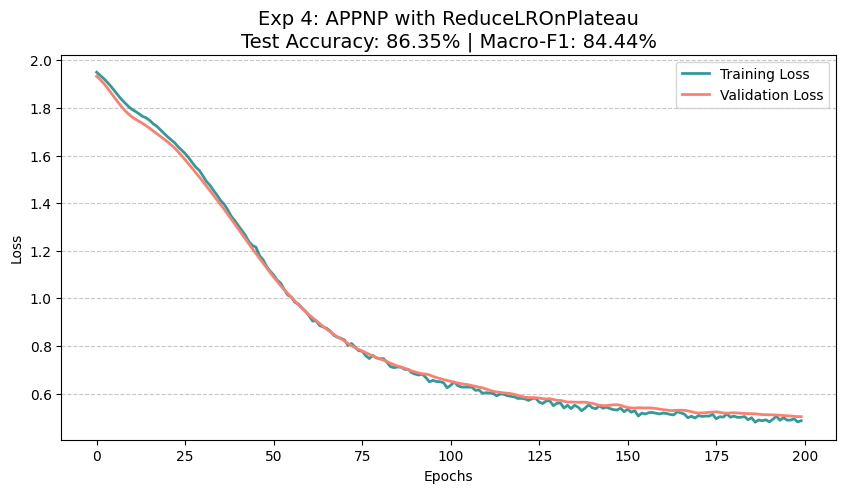

In [86]:
print("--- EXPERIMENT 4: DYNAMIC LEARNING RATE (APPNP) ---")

# 1. Initialize Standard Champion Model
model_exp4 = APPNP_Standard(CHAMPION_HID_DIM, CHAMPION_DROPOUT, CHAMPION_K, CHAMPION_ALPHA).to(device)

# 2. Train with Scheduler turned ON
t_loss4, v_loss4, acc4, f1_4 = run_experiment(
    model_exp4, data_exp2, lr=CHAMPION_LR, use_scheduler=True
)

# 3. Visuals
plot_experiment(t_loss4, v_loss4, "Exp 4: APPNP with ReduceLROnPlateau", acc4, f1_4)


In [87]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# 📊 Comparative Diagnostic Analysis

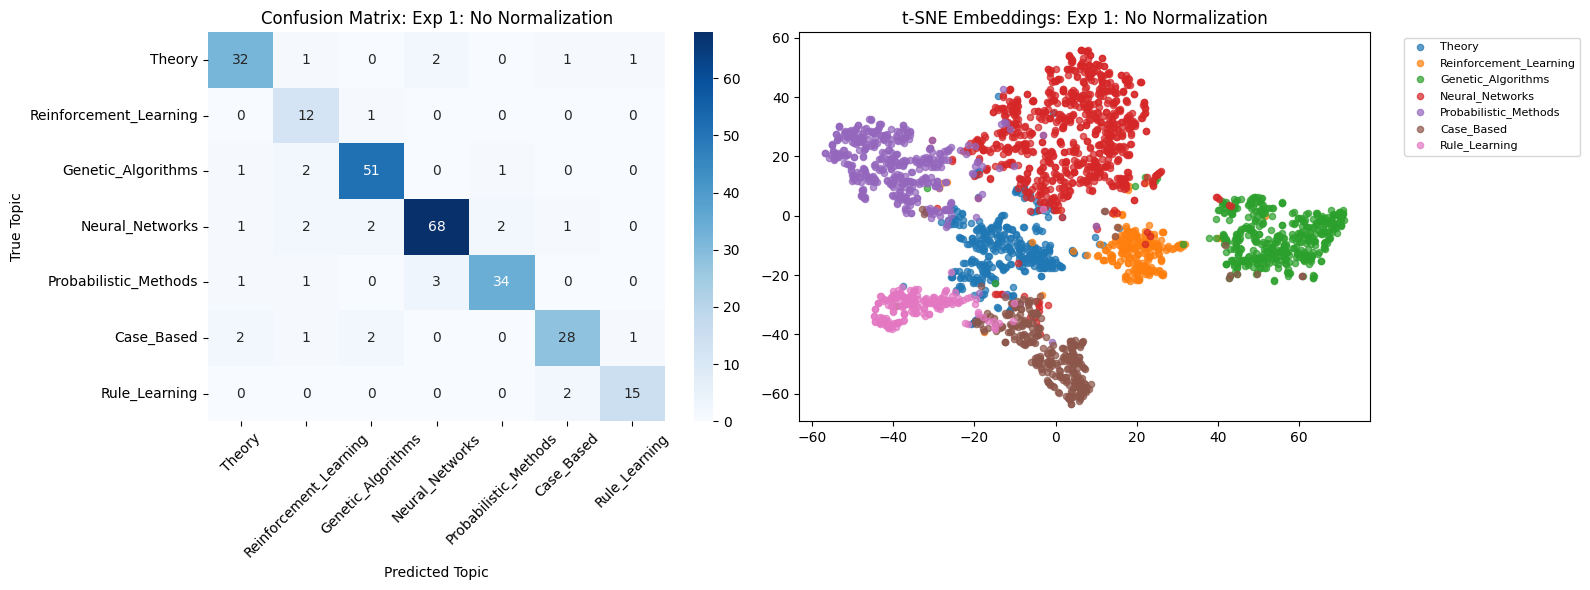

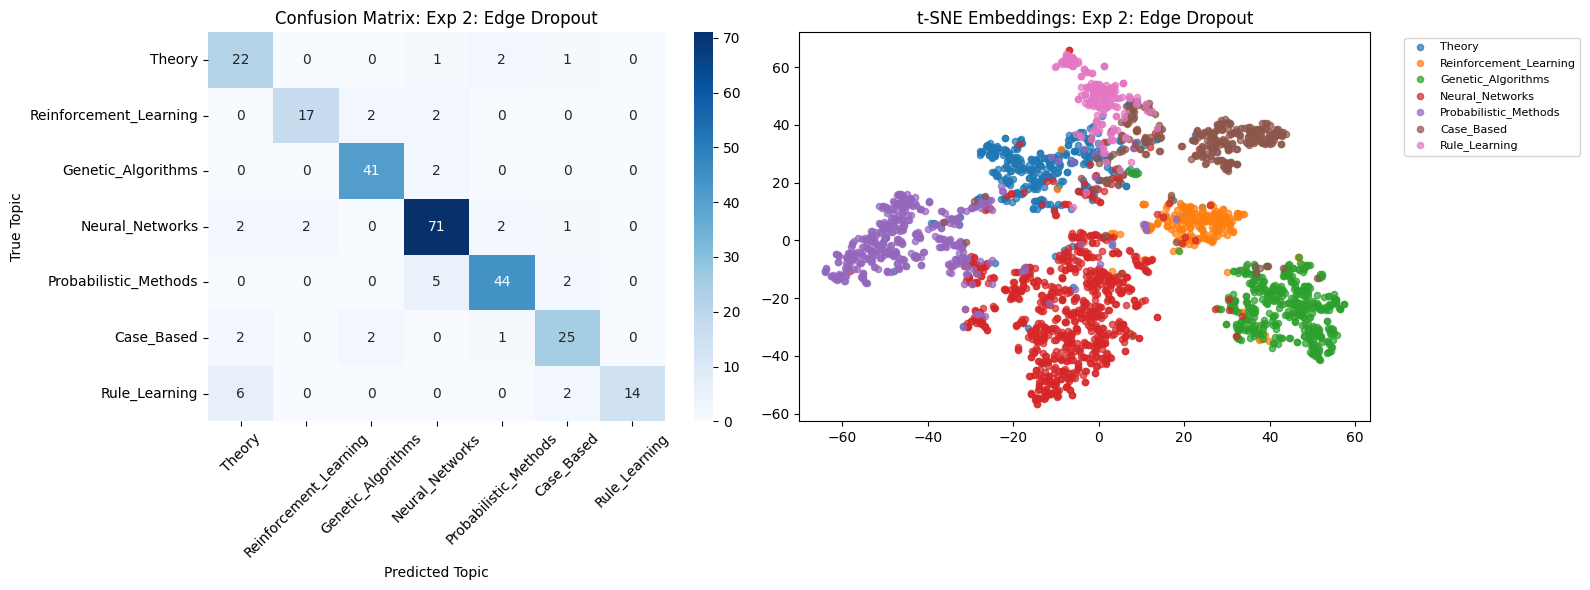

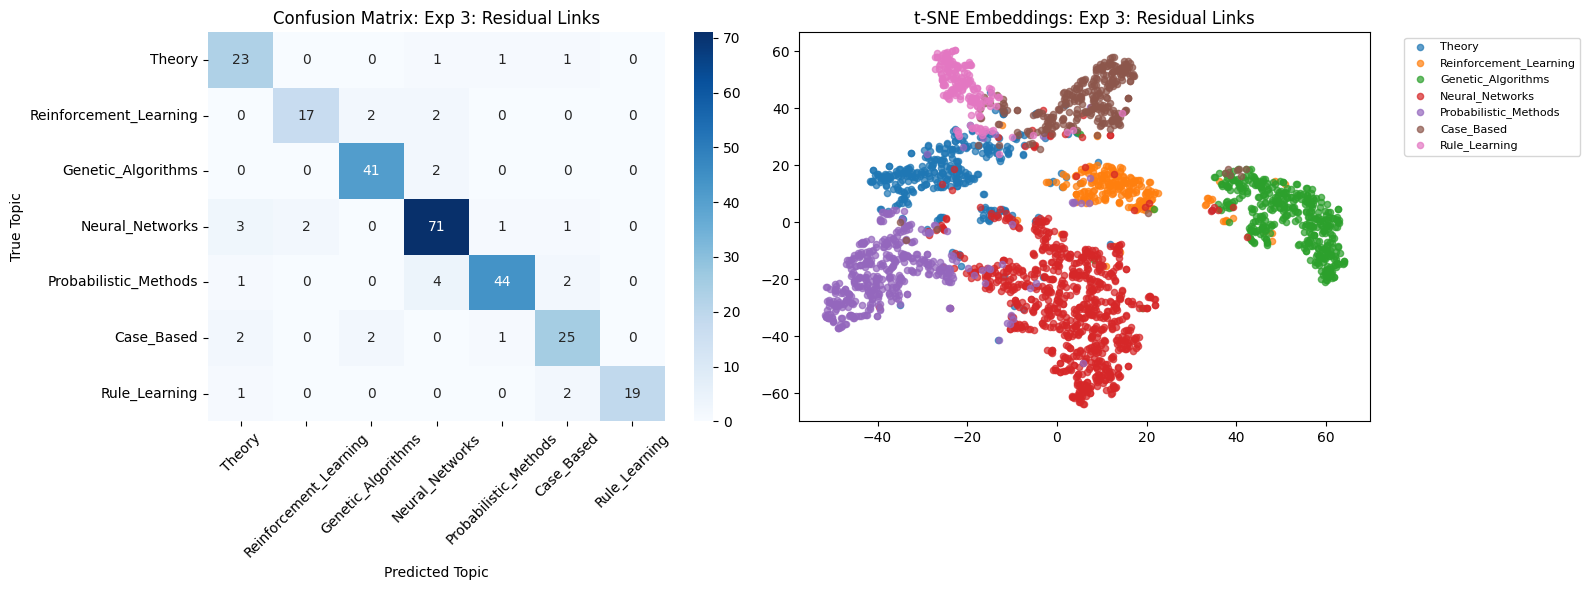

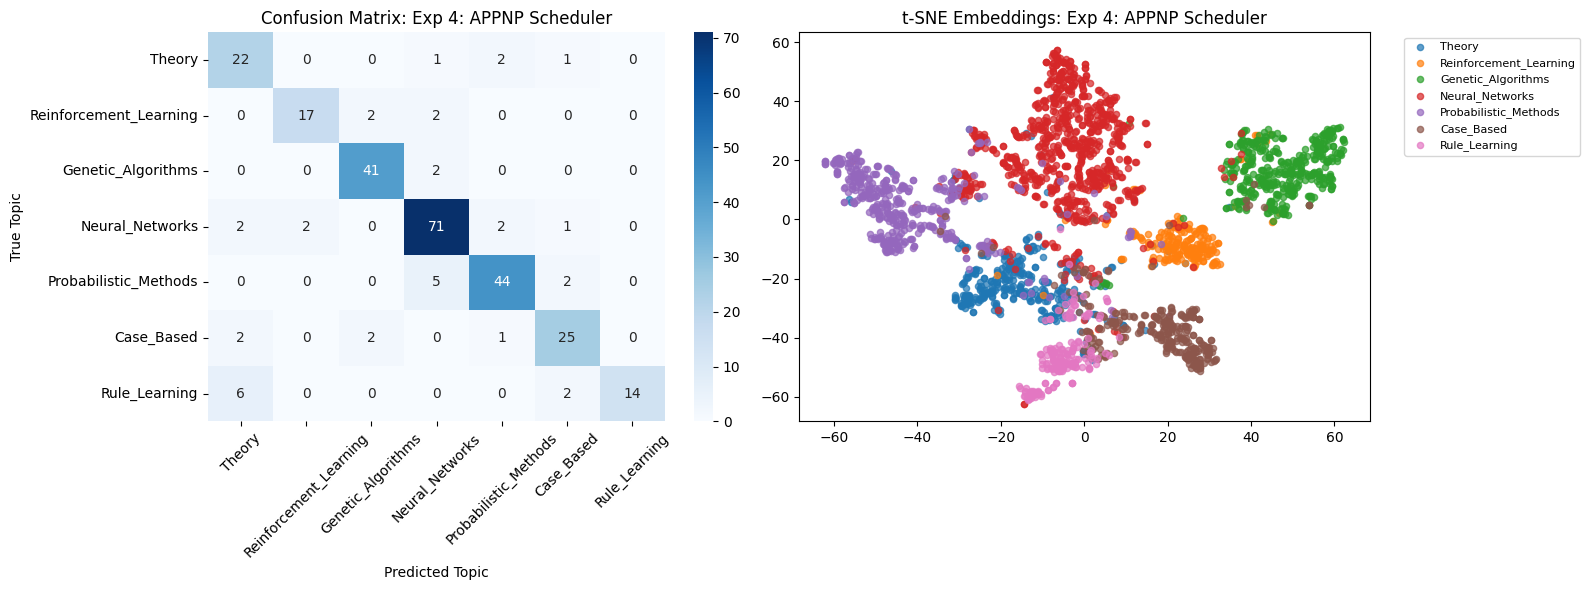

In [88]:
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import numpy as np

# Helper function to generate both visuals for any trained model
def plot_advanced_diagnostics(model, data, title):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        embeddings = out.cpu().numpy()
        preds = out.argmax(dim=1)[data.test_mask].cpu().numpy()
        trues = data.y[data.test_mask].cpu().numpy()
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(trues, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=topic_map.values(), yticklabels=topic_map.values())
    axes[0].set_title(f"Confusion Matrix: {title}")
    axes[0].set_xlabel("Predicted Topic")
    axes[0].set_ylabel("True Topic")
    axes[0].tick_params(axis='x', rotation=45)
    
    # --- 2. t-SNE Plot ---
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    labels = data.y.cpu().numpy()
    for i in range(dataset_exp2.num_classes):
        indices = np.where(labels == i)
        axes[1].scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], 
                        label=topic_map[i], alpha=0.7, s=20)
    
    axes[1].set_title(f"t-SNE Embeddings: {title}")
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# You need your topic map from earlier
topic_map = {
    0: "Theory", 1: "Reinforcement_Learning", 2: "Genetic_Algorithms", 
    3: "Neural_Networks", 4: "Probabilistic_Methods", 5: "Case_Based", 6: "Rule_Learning"
}

# Run it for your experiments! (Uncomment the ones you want to see)
plot_advanced_diagnostics(model_exp1, data_exp1, "Exp 1: No Normalization")
plot_advanced_diagnostics(model_exp2, data_exp2, "Exp 2: Edge Dropout")
plot_advanced_diagnostics(model_exp3, data_exp2, "Exp 3: Residual Links")
plot_advanced_diagnostics(model_exp4, data_exp2, "Exp 4: APPNP Scheduler")

In [89]:
import os
import pandas as pd
import torch

os.makedirs("app_data", exist_ok=True)

# 1. Save the APPNP Champion
torch.save(model_exp3.state_dict(), "app_data/champion_appnp.pth")

# 2. Save the Graph Tensors for the Dashboard
torch.save(data_exp2.x.cpu(), "app_data/cora_features.pt")
torch.save(data_exp2.edge_index.cpu(), "app_data/cora_edge_index.pt")

# 3. Save Node/Edge Metadata
topic_map = {0: "Theory", 1: "Reinforcement Learning", 2: "Genetic Algorithms", 
             3: "Neural Networks", 4: "Probabilistic Methods", 5: "Case Based", 6: "Rule Learning"}

nodes_df = pd.DataFrame({'node_id': range(data_exp2.num_nodes), 'true_label': data_exp2.y.cpu().numpy()})
nodes_df['Topic_Name'] = nodes_df['true_label'].map(topic_map)
nodes_df['Paper_Title'] = nodes_df.apply(lambda r: f"{r['Topic_Name']} Study (Node #{int(r['node_id'])})", axis=1)
nodes_df.to_csv("app_data/cora_nodes.csv", index=False)

edges_df = pd.DataFrame({'source': data_exp2.edge_index[0].cpu().numpy(), 'target': data_exp2.edge_index[1].cpu().numpy()})
edges_df.to_csv("app_data/cora_edges.csv", index=False)

print("✅ APPNP Champion and Graph Data saved to app_data/")

✅ APPNP Champion and Graph Data saved to app_data/
